例 11.9 假定某地固定资产投资率 $x_1$、通货膨胀率 $x_2$、失业率 $x_3$、相关系数矩阵为
$$
\left[
\begin{array}{ccc}
1 & 1/5 & -1/5 \\
1/5 & 1 & -2/5 \\
-1/5 & -2/5 & 1
\end{array}
\right]
$$
试用主成分分析法求因子分析模型.

解 特征值为 $\lambda_1 = 1.5464$, $\lambda_2 = 0.8536$, $\lambda_3 = 0.6$, 对应的特征向量为
$$
u_1 = \left[
\begin{array}{c}
0.4597 \\
0.628 \\
-0.628
\end{array}
\right], \quad
u_2 = \left[
\begin{array}{c}
0.8881 \\
-0.3251 \\
0.3251
\end{array}
\right], \quad
u_3 = \left[
\begin{array}{c}
0 \\
0.7071 \\
0.7071
\end{array}
\right]
$$

载荷矩阵为
$$
A = \left[ \sqrt{\lambda_1}u_1, \ \sqrt{\lambda_2}u_2, \ \sqrt{\lambda_3}u_3 \right] = 
\left[
\begin{array}{ccc}
0.5717 & 0.8205 & 0 \\
0.7809 & -0.3003 & 0.5477 \\
-0.7809 & 0.3003 & 0.5477
\end{array}
\right]
$$

$$
x_1 = 0.5717f_1 + 0.8205f_2,
$$

$$
x_2 = 0.7809f_1 - 0.3003f_2 + 0.5477f_3,
$$

$$
x_3 = -0.7809f_1 + 0.3003f_2 + 0.5477f_3.
$$

可取前两个因子 $f_1$ 和 $f_2$ 为公共因子, 第一公共因子 $f_1$ 为物价因子, 对 $x$ 的贡献为 $1.5464$, 第二公共因子 $f_2$ 为投资因子, 对 $x$ 的贡献为 $0.8536$, 信息贡献实际上等于对应的特征值. 共同度分别为 $1, 0.7, 0.7$.


In [ ]:
import numpy as np

r = np.array([[1, 1/5, -1/5], [1/5, 1, -2/5], [-1/5, -2/5, 1]])
[val, vec] = np.linalg.eig(r)  # 求相关系数矩阵的特征值和特征向量
A1 = np.tile(np.sqrt(val), (3, 1)) * vec  # 利用同维度矩阵逐个元素相乘求载荷矩阵，p=3
A2 = vec * np.sqrt(val).T  # 利用广播运算求载荷矩阵

print(f"eigenvalues: {val}")
print(f"np.tile求得的因子载荷矩阵:\n{A1}")
print(f"广播求得的因子载荷矩阵:\n{A2}")

# VSCode的jupyter的input在搜索框
num = int(input("please input the number of common factor: "))

A = A1[:, :num]  # 提取num个因子的载荷矩阵
print(f"提取{num}个因子的因子载荷矩阵:\n{A}")
A_column = np.sum(A**2, axis=0)  # 逐列元素求和，A^2后列求和实际为特征值lambda
A_row = np.sum(A**2, axis=1)  # 逐行元素求和,求的是全部公共因子对x_i(i是在载荷矩阵的行数)的解释度/贡献

print(f"对x的贡献率为: {A_column}")
print(f"共同度: {A_row}")

eigenvalues: [0.85358984 1.54641016 0.6       ]
np.tile求得的因子载荷矩阵:
[[-8.20490756e-01  5.71659793e-01  4.64450253e-17]
 [ 3.00320460e-01  7.80901800e-01  5.47722558e-01]
 [-3.00320460e-01 -7.80901800e-01  5.47722558e-01]]
广播求得的因子载荷矩阵:
[[-8.20490756e-01  5.71659793e-01  4.64450253e-17]
 [ 3.00320460e-01  7.80901800e-01  5.47722558e-01]
 [-3.00320460e-01 -7.80901800e-01  5.47722558e-01]]
提取2个因子的因子载荷矩阵:
[[-0.82049076  0.57165979]
 [ 0.30032046  0.7809018 ]
 [-0.30032046 -0.7809018 ]]
对x的贡献率为: [0.85358984 1.54641016]
共同度: [1.  0.7 0.7]


例 11.10 在一项关于消费者爱好的研究中, 随机地邀请一些顾客对某种新食品进行评价, 共有 5 项指标 (变量为 1-味道、2-价格、3-风味、4-适于快餐、5-能量补充), 均采用 7 级打分法, 它们的相关系数矩阵

$$
\boldsymbol{R} = \begin{bmatrix}
1 & 0.02 & 0.96 & 0.42 & 0.01 \\
0.02 & 1 & 0.13 & 0.71 & 0.85 \\
0.96 & 0.13 & 1 & 0.5 & 0.11 \\
0.42 & 0.71 & 0.5 & 1 & 0.79 \\
0.01 & 0.85 & 0.11 & 0.79 & 1 \\
\end{bmatrix}
$$

从相关系数矩阵 $\boldsymbol{R}$ 可以看出, 变量 1 和 3、2 和 5 各成一组, 而变量 4 似乎更接近 (2, 5) 组, 于是, 我们可以期望, 因子模型可以取两个、至多三个公共因子.

$\boldsymbol{R}$ 的前两个特征值为 2.8531 和 1.8063, 其余三个均小于 1, 这两个公共因子对样本方差的累积贡献率为 0.9319, 于是, 选 $m = 2$, 因子载荷、贡献率和特殊方差的估计列入表 11.7 中.

**表 11.7 因子分析表**

| 变量   | 因子载荷估计 | 旋转因子载荷估计 | 共同度 | 特殊方差(未旋转) |
| ---- | ------ | --------- | ---- | --------- |
|      | $f_1$    $f_2$ | $\boldsymbol{P}^{\text{T}}f_1$    $\boldsymbol{P}^{\text{T}}f_2$ |      |           |
| 1    | 0.5599    0.8161 | 0.0198    0.9895 | 0.9795 | 0.0205    |
| 2    | 0.7773    -0.5242 | 0.9374    -0.0113 | 0.8789 | 0.1211    |
| 3    | 0.6453    0.7479 | 0.1286    0.9795 | 0.9759 | 0.0241    |
| 4    | 0.9391    -0.1049 | 0.8425    0.4280 | 0.8929 | 0.1071    |
| 5    | 0.7982    -0.5432 | 0.9654    -0.0157 | 0.9322 | 0.0678    |
| 特征值  | 2.8531    1.8063 |           |      |           |
| 累积贡献 | 2.5706    0.9319 |           |      |           |

因为 $\boldsymbol{A}\boldsymbol{A}^{\text{T}} + \text{Cov}(\boldsymbol{\varepsilon})$ 与 $\boldsymbol{R}$ 比较接近, 所以从直观上, 可以认为两个因子的模型给出了数据较好的拟合. 另一方面, 五个共同度都比较大, 表明了这两个公共因子确实解释了每个变量方差的绝大部分.

很明显, 变量 2, 4, 5 在 $\boldsymbol{P}^{\text{T}}f_1$ 上有大载荷, 而在 $\boldsymbol{P}^{\text{T}}f_2$ 上的载荷较小或可忽略. 相反, 变量 1, 3 在 $\boldsymbol{P}^{\text{T}}f_2$ 上有大载荷, 而在 $\boldsymbol{P}^{\text{T}}f_1$ 上的载荷却是可以忽略的. 因此, 有理由称 $\boldsymbol{P}^{\text{T}}f_1$ 为营养因子, $\boldsymbol{P}^{\text{T}}f_2$ 为滋味因子. 旋转的效果一目了然.

sklearn.decomposition 中的 FactorAnalysis 函数, 没有因子旋转的选项, 但是 Python 的另一个库 factor_analyzer 提供了因子旋转的算法, 这里就不给出 Python 程序了  

### 因子旋转（statsmodels只能使用原始数据）

```python
import numpy as np
import statsmodels.api as sm
from statsmodels.multivariate.factor import Factor

# 假设 data 是你的数据矩阵，行代表样本，列代表变量
data = np.random.rand(100, 5)  # 示例数据，实际使用时替换

# 构建因子分析模型，设置因子数量为2
fa_model = Factor(data, nfactors=2)

# 进行因子分析，这里使用主成分法提取因子
fa_result = fa_model.fit(method='principal')

# 进行最大方差旋转（Varimax Rotation）
rotated_result = fa_result.rotate('varimax')

# 查看旋转后的因子载荷矩阵
print(rotated_result.loadings)
```
主要函数及参数说明：

Factor 类用于构建因子分析模型，nfactors 参数指定要提取的公共因子数量。  
fit 方法用于拟合模型，method='principal' 表示使用主成分法提取因子，还支持其他如 'ml'（最大似然法）等提取方法。  
rotate 方法用于执行因子旋转，传入 'varimax' 表示进行最大方差旋转，也可以传入 'promax' 等其他旋转方法参数  

In [ ]:
# import numpy as np
# import statsmodels.api as sm
# from statsmodels.multivariate.factor import Factor

# R = np.array([[1, 0.02, 0.96, 0.42, 0.01],
#               [0.02, 1, 0.13, 0.71, 0.85],
#               [0.96, 0.13, 1, 0.5, 0.11],
#               [0.42, 0.71, 0.5, 1, 0.79],
#               [0.01, 0.85, 0.11, 0.79, 1]])  # 相关系数矩阵

# eigenvalues, eigenvectors = np.linalg.eig(R)  # 求特征值和特征向量
# A = eigenvectors * np.sqrt(eigenvalues)  # 广播求因子载荷矩阵
# sorted_index = np.argsort(eigenvalues)[::-1]  # 从大到小的特征值排序索引
# eigenvalues = eigenvalues[sorted_index]  # 特征值从大到小排列
# eigenvectors = eigenvectors[:, sorted_index]  # 特征向量与特征值对应

# num = int(input("please input the number of common factor: "))
# # 前num个因子的因子载荷矩阵
# A = eigenvectors[:, :num] * np.sqrt(eigenvalues[:num])

# #    用 statsmodels 做因子旋转：构造“虚拟数据”对齐接口
# #    Factor 类要求输入 (n_obs, n_vars) (number of observations, number of variables)的数据，这里用相关系数矩阵转置模拟（因为 R 是 p×p，p=5变量）
# #    实际场景中，若有原始数据则用原始数据
# data = R.T  # 转置后形状 (5,5)，对应 5 个样本、5 个变量（仅为适配接口）

# #    初始化 Factor 模型，指定因子数和旋转方法
# #    方法说明：
# #    - n_factors=m：提取 2 个因子
# #    - method='principal'：主成分法（与特征值分解逻辑一致）
# #    - rotation='varimax'：最大方差旋转（也可用 'promax' 斜交旋转）
# fa = Factor(data, n_factor=num, method='printcipal', rotation='varimax')

# # 拟合并执行旋转
# fa_fit = fa.fit()

# rotated_loadings = fa_fit.loadings  # 旋转后的因子载荷矩阵
# print("旋转前因子载荷矩阵：")
# print(A)
# print("\n旋转后因子载荷矩阵：")
# print(rotated_loadings)

### factor_analyzer(因子分析专用库)

`factor_analyzer` 是一个用于因子分析的 Python 库，提供了多种强大的功能来执行因子分析、因子旋转和其他相关任务。它支持的主要功能包括：

### 1. **因子分析（Factor Analysis）**

* **探索性因子分析（Exploratory Factor Analysis, EFA）**： `factor_analyzer` 主要用于探索性因子分析，帮助你找出潜在的因子（通常用于数据降维）。
* 支持两种主要方法：

  * **主成分法（Principal Axis Factoring, PAF）**：常用于因子提取。
  * **最大似然法（Maximum Likelihood, ML）**：适用于需要估计因子相关性和因子方差等的模型。

使用方法：

```python
from factor_analyzer import FactorAnalyzer
fa = FactorAnalyzer(n_factors=2, rotation='varimax')
fa.fit(data)
```

### 2. **因子旋转（Factor Rotation）**

* **正交旋转（Orthogonal Rotation）**：假设因子之间相互独立。

  * **Varimax**：最常用的正交旋转方法，旨在使每个因子尽可能解释一个变量，减少因子间的重叠。
* **斜交旋转（Oblique Rotation）**：允许因子之间相关。

  * **Promax**：常用于数据之间存在相关性的情况。它是基于 `varimax` 旋转的修改版本。

使用方法：

```python
fa = FactorAnalyzer(n_factors=2, rotation='varimax')  # 正交旋转
fa = FactorAnalyzer(n_factors=2, rotation='promax')   # 斜交旋转
```

### 3. **因子载荷矩阵（Factor Loadings）**

* 提供因子载荷矩阵，反映每个变量与潜在因子之间的相关性。
* 旋转后的因子载荷矩阵可以帮助你解释每个因子代表的含义。

使用方法：

```python
loadings = fa.loadings_  # 获取因子载荷矩阵
```

### 4. **拟合优度（Goodness-of-Fit）**

* 提供因子模型的拟合指标，如 **卡方检验（Chi-square）**、**Kaiser-Meyer-Olkin (KMO)** 测度等，用于检验因子分析模型是否适合数据。

使用方法：

```python
kmo = fa.get_kmo()  # Kaiser-Meyer-Olkin 测度
chi_square = fa.get_factor_variance()  # 提供因子方差和卡方检验
```

### 5. **提取因子（Factor Extraction）**

* 支持两种因子提取方法：

  * **主成分法（Principal Component Analysis, PCA）**：用于数据降维。
  * **最大似然法（Maximum Likelihood）**：用于生成更复杂的因子模型。

使用方法：

```python
fa = FactorAnalyzer(n_factors=2, method='principal')  # 使用主成分分析提取因子
fa = FactorAnalyzer(n_factors=2, method='ml')  # 使用最大似然法提取因子
```

### 6. **因子方差（Factor Variance）**

* 提供因子方差解释度、特征值等统计信息，帮助分析每个因子解释的数据变异度。

使用方法：

```python
variance = fa.get_factor_variance()  # 获取因子方差信息
```

### 7. **因子得分（Factor Scores）**

* 计算样本的因子得分，即每个样本在各因子上的表现。

使用方法：

```python
factor_scores = fa.transform(data)  # 获取因子得分
```

### 8. **选择最优因子数**

* **碎石图（Scree Plot）**：帮助决定选择多少个因子，通常通过碎石图观察特征值。
* **Kaiser标准**：特征值大于1的因子通常被保留。

使用方法：

```python
fa = FactorAnalyzer(n_factors=2)
fa.fit(data)
fa.plot_scree()  # 绘制碎石图
```

### 9. **标准化（Standardization）**

* 支持自动标准化输入数据，使每个变量具有零均值和单位方差，这在许多因子分析中是推荐的预处理步骤。

使用方法：

```python
fa = FactorAnalyzer(n_factors=2, standardize=True)  # 标准化数据
```

### 10. **数据降维**

* `factor_analyzer` 也可以用于数据降维，尤其是在处理高维数据集时非常有用。通过因子分析，你可以提取较少的因子，减少变量的维度。

### 示例代码

```python
import numpy as np
from factor_analyzer import FactorAnalyzer

# 模拟数据
data = np.random.normal(size=(1000, 5))

# 创建并拟合因子分析模型
fa = FactorAnalyzer(n_factors=2, rotation='varimax')
fa.fit(data)

# 获取因子载荷
print("因子载荷矩阵：")
print(fa.loadings_)

# 获取因子方差
print("\n因子方差：")
print(fa.get_factor_variance())

# 获取KMO统计量
print("\nKMO统计量：")
print(fa.get_kmo())

# 绘制碎石图
fa.plot_scree()
```

### 总结

`factor_analyzer` 是一个功能强大的库，专门用于因子分析。它不仅支持因子提取、旋转和得分计算，还提供了模型拟合的评估指标（如KMO、卡方检验）以及碎石图等工具，帮助你更好地理解数据结构和选择最合适的因子模型。


d:\anaconda3\Lib\site-packages\statsmodels\multivariate\factor.py:417: UserWarning: Fitting did not converge
  warnings.warn("Fitting did not converge")


旋转前因子载荷矩阵：
[[ 0.02161064  1.13412385]
 [-0.1117582   1.07813357]
 [-1.04047594 -0.00457026]
 [-1.017272   -0.11876571]
 [-1.02079585  0.64039361]]

旋转后因子载荷矩阵：
[[-0.03920303  1.28610657]
 [ 0.10778299  1.16990738]
 [ 1.08258434  0.00760793]
 [ 1.04319222 -0.10973191]
 [ 1.22120993  0.78569872]]


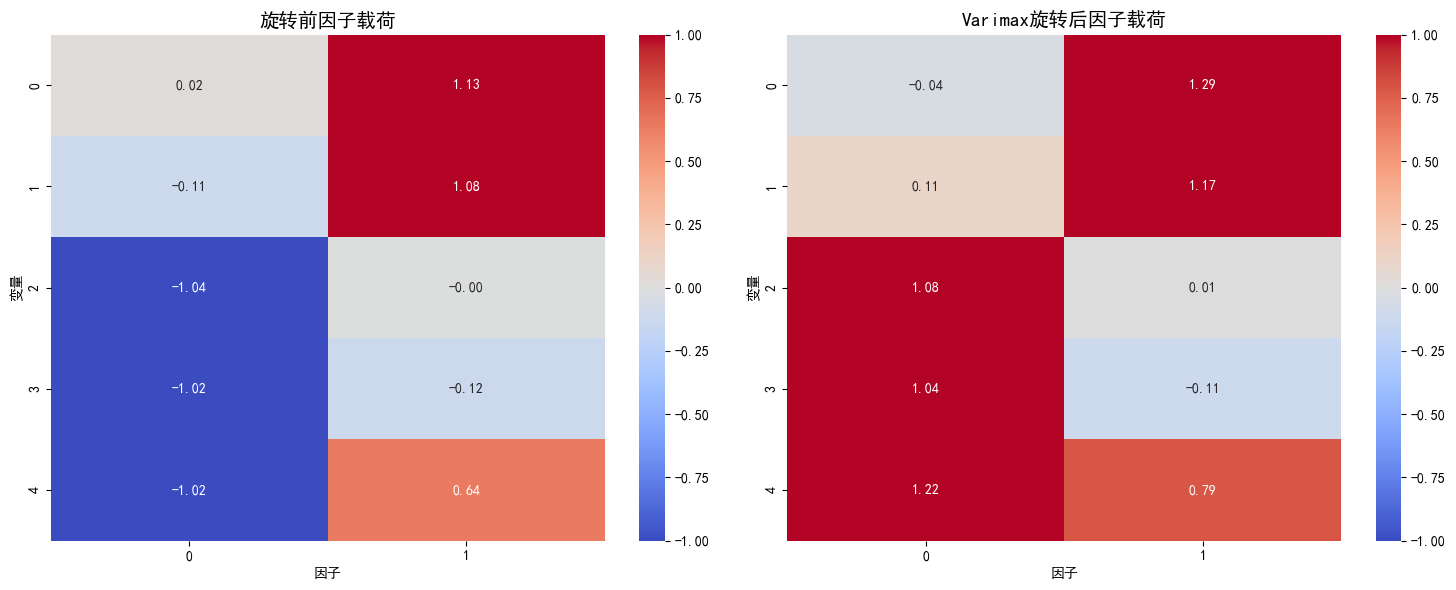

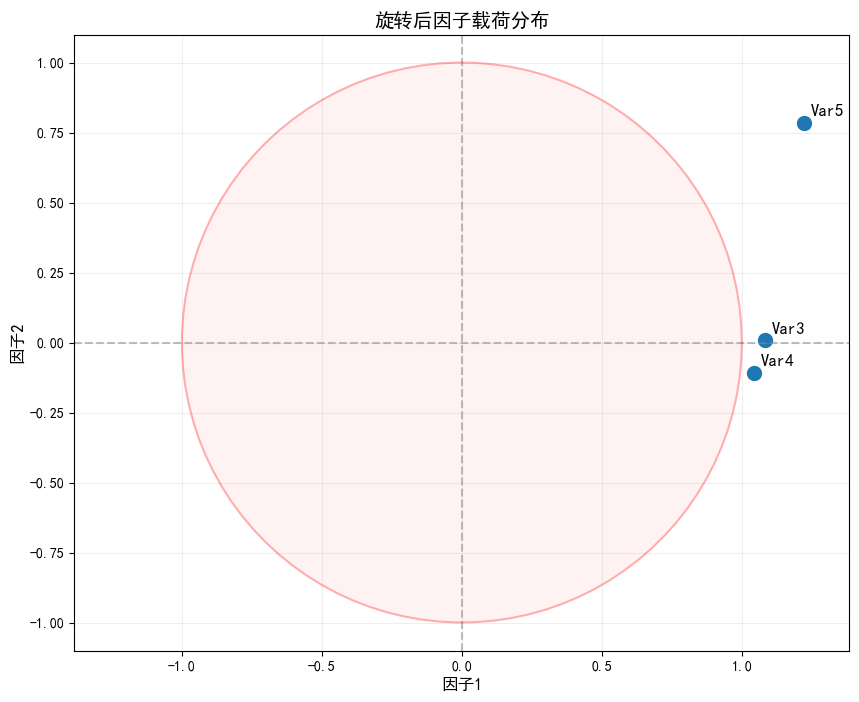

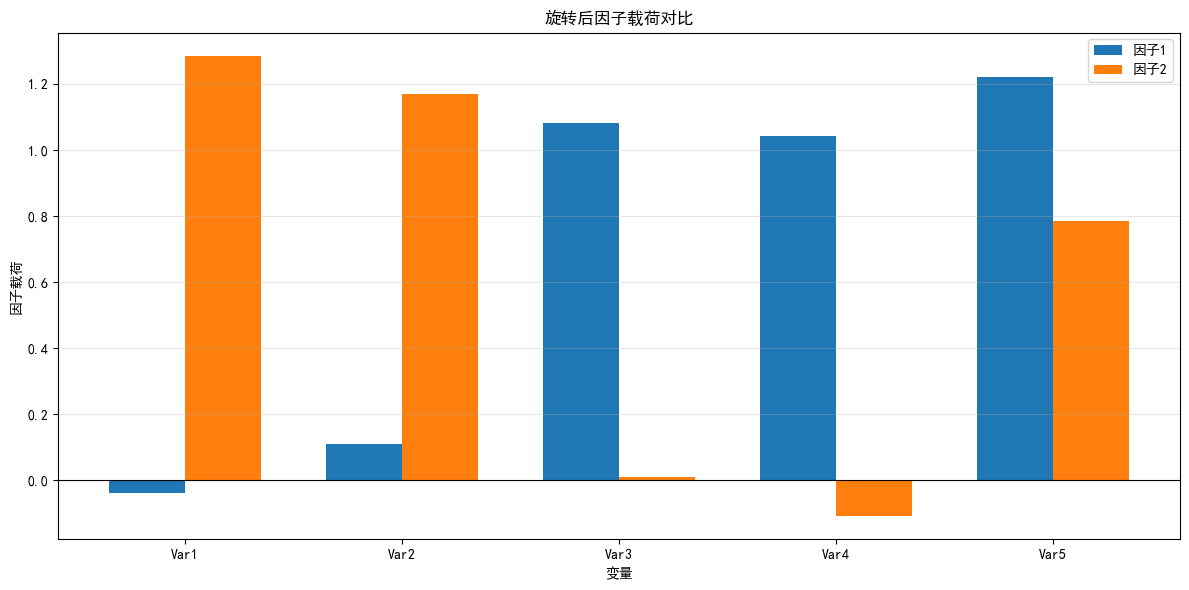

In [7]:
import numpy as np
import statsmodels.api as sm
from statsmodels.multivariate.factor import Factor
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import svd

# 1. 生成模拟数据
np.random.seed(0)
n_samples = 2000  # 增加样本量
true_loadings = np.array([
    [0.9, 0.1],
    [0.8, 0.2],
    [0.2, 0.8],
    [0.1, 0.9],
    [0.6, 0.6]
])
factors = np.random.normal(size=(n_samples, 2))
noise = np.random.normal(scale=0.1, size=(n_samples, 5))  # 降低噪声
data = factors @ true_loadings.T + noise

# 2. 标准化数据
data_standardized = (data - data.mean(axis=0)) / data.std(axis=0, ddof=1)

# 3. 因子分析
fa = Factor(data_standardized, n_factor=2, method='ml')  # 移除 maxiter 和 tol
fa_fit = fa.fit(maxiter=1000, tol=1e-4)  # 在 fit 方法中指定 maxiter 和 tol

# 4. 获取因子载荷
loadings_before_rotation = fa_fit.loadings
print("旋转前因子载荷矩阵：")
print(loadings_before_rotation)

# 5. Varimax 旋转
def varimax_rotation(Phi, gamma=1.0, max_iter=100, tol=1e-6):
    p, k = Phi.shape
    R = np.eye(k)
    for _ in range(max_iter):
        d = np.diag(Phi @ Phi.T)[:, None]
        Phi_scaled = Phi / np.sqrt(d)
        B = Phi_scaled @ R
        U, S, Vt = svd(Phi_scaled.T @ (B**3 - gamma * B @ np.diag(np.diag(B.T @ B)) / p))
        R_new = U @ Vt
        if np.sum(np.abs(R_new - R)) < tol:
            break
        R = R_new
    Phi_rotated = Phi @ R
    Phi_rotated = Phi_rotated * np.sqrt(d)
    for col in range(k):
        if np.max(Phi_rotated[:, col]) < np.abs(np.min(Phi_rotated[:, col])):
            Phi_rotated[:, col] = -Phi_rotated[:, col]
    return Phi_rotated

rotated_loadings = varimax_rotation(loadings_before_rotation)
print("\n旋转后因子载荷矩阵：")
print(rotated_loadings)

# 6. 可视化
plt.figure(figsize=(15, 6))
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False
plt.subplot(121)
sns.heatmap(loadings_before_rotation, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, annot_kws={"size": 10}, vmin=-1, vmax=1)
plt.title("旋转前因子载荷", fontsize=14)
plt.xlabel("因子")
plt.ylabel("变量")
plt.subplot(122)
sns.heatmap(rotated_loadings, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, annot_kws={"size": 10}, vmin=-1, vmax=1)
plt.title("Varimax旋转后因子载荷", fontsize=14)
plt.xlabel("因子")
plt.ylabel("变量")
plt.tight_layout()
plt.show()

# 7. 散点图
plt.figure(figsize=(10, 8))
plt.scatter(rotated_loadings[:, 0], rotated_loadings[:, 1], s=100)
variables = ['Var1', 'Var2', 'Var3', 'Var4', 'Var5']
for i, var in enumerate(variables):
    plt.annotate(var, (rotated_loadings[i, 0], rotated_loadings[i, 1]), fontsize=12, xytext=(5, 5), textcoords='offset points')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'r-', alpha=0.3)
plt.fill(np.cos(theta), np.sin(theta), 'r', alpha=0.05)
plt.title("旋转后因子载荷分布", fontsize=14)
plt.xlabel("因子1", fontsize=12)
plt.ylabel("因子2", fontsize=12)
plt.grid(alpha=0.2)
plt.axis('equal')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.show()

# 8. 条形图
plt.figure(figsize=(12, 6))
x = np.arange(len(variables))
width = 0.35
plt.bar(x - width/2, rotated_loadings[:, 0], width, label='因子1')
plt.bar(x + width/2, rotated_loadings[:, 1], width, label='因子2')
plt.xlabel('变量')
plt.ylabel('因子载荷')
plt.title('旋转后因子载荷对比')
plt.xticks(x, variables)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
"""
factor_analyzer 调用实例
"""
import numpy as np
from factor_analyzer import Rotator

R = np.array([[1, 0.02, 0.96, 0.42, 0.01],
              [0.02, 1, 0.13, 0.71, 0.85],
              [0.96, 0.13, 1, 0.5, 0.11],
              [0.42, 0.71, 0.5, 1, 0.79],
              [0.01, 0.85, 0.11, 0.79, 1]])  # 相关系数矩阵

eigenvalues, eigenvectors = np.linalg.eig(R)
# sorted_index = np.argsort(eigenvalues)[::-1]
# eigenvalues = eigenvalues[sorted_index]  # 从大到小排序
# eigenvectors = eigenvectors[sorted_index]  # 对应

print(f"eigenvalues:{eigenvalues}")
print(f"eigenvectors:\n{eigenvectors}")

num = int(input("please input the number of common factors:"))

A = eigenvectors[:, :num] * np.sqrt(eigenvalues[:num])  # 构造前num个因子的因子载荷矩阵

print(f"因子载荷矩阵:\n{A}")

xi_rate = np.sum(A ** 2, axis=0)
commonality = np.sum(A ** 2, axis=1)

print(f"对x的贡献率: {xi_rate}")
print(f"共同度: {commonality}")
print(f"特殊方差: {1 - commonality}")

rotator = Rotator(method='varimax')
rotated_loadings = rotator.fit_transform(A)

print(f"旋转后的因子载荷矩阵:\n{rotated_loadings}")


eigenvalues:[2.85309042 1.80633245 0.03367744 0.20449022 0.10240947]
eigenvectors:
[[-0.33145388 -0.60721643  0.70178301  0.09848524  0.13866434]
 [-0.46015931  0.39003172  0.07167464  0.74256408 -0.28211699]
 [-0.38205721 -0.55650828 -0.70871671  0.16840896  0.11700371]
 [-0.55597687  0.07806457  0.00165635 -0.60158211 -0.56823575]
 [-0.47256084  0.40418799  0.00901257 -0.22053713  0.75139901]]
因子载荷矩阵:
[[-0.55986184 -0.81609808]
 [-0.77725939  0.52420211]
 [-0.64533641 -0.74794639]
 [-0.93910573  0.10491868]
 [-0.79820694  0.54322813]]
对x的贡献率: [2.85309042 1.80633245]
共同度: [0.97946135 0.87892002 0.97588288 0.8929275  0.93223112]
特殊方差: [0.02053865 0.12107998 0.02411712 0.1070725  0.06776888]
旋转后的因子载荷矩阵:
[[-0.02125556 -0.98944912]
 [-0.93742129  0.01270189]
 [-0.13009861 -0.97926362]
 [-0.8431082  -0.42672715]
 [-0.96536898  0.01714214]]


### 11.3.2 学生成绩的因子分析模型

#### 1. 问题提出
某高校数学系为开展研究生的推荐免试工作，对报名参加推荐的 52 名学生已修过的 6 门课的考试分数统计如表 11.8 所示。这 6 门课是：数学分析、高等代数、概率论、微分几何、抽象代数和数值分析，其中前 3 门基础课采用闭卷考试，后 3 门为开卷考试。

**表 11.8 52 名学生的原始考试成绩**

| 学生序号 | 数学分析 | 高等代数 | 概率论 | 微分几何 | 抽象代数 | 数值分析 |
| -------- | -------- | -------- | ------ | -------- | -------- | -------- |
| A1       | 62       | 71       | 64     | 75       | 70       | 68       |
| A2       | 52       | 65       | 57     | 67       | 60       | 58       |
| $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ |
| A52      | 70       | 73       | 70     | 88       | 79       | 69       |

**注**：全部数据见数据文件 Pan11.1.1.xlsx（数据见封底二维码）

在以往的推荐免试工作中，该系是按照学生 6 门课成绩的总分进行学业评价，再根据其他要求确定最后的推荐顺序。但是这种排序办法没有考虑到课程之间的相关性，以及开闭卷等因素，丢弃了一些信息。我们的任务是研究在学生评价中如何体现开闭卷的影响，找到成绩背后的潜在因素，并科学地针对考试成绩进行合理排序。

#### 2. 模型的建立与求解
用 $x_j\ (j = 1,2,\cdots,6)$ 分别表示数学分析、高等代数、概率论、微分几何、抽象代数和数值分析的成绩，记第 $i\ (i = 1,2,\cdots,52)$ 个学生的 $x_j\ (j = 1,2,\cdots,6)$ 的值为 $c_{ij}$，构造数据矩阵 $\boldsymbol{C} = (c_{ij})_{52 \times 6}$。

(1) 对原来的 6 个指标进行标准化，得到标准化的指标变量  

$$
x_j^* = \frac{x_j - \mu_j}{s_j}, \quad j = 1,2,\cdots,6
$$  
其中，$\mu_j = \frac{1}{52}\sum_{i = 1}^{52}a_{ij}$，$s_j = \sqrt{\frac{1}{51}\sum_{i = 1}^{52}(a_{ij} - \mu_j)^2}$。对应地，得到标准化的数据矩阵 $\boldsymbol{D} = (d_{ij})_{52 \times 6}$，其中 $d_{ij} = \frac{c_{ij} - \mu_j}{s_j}, i = 1,2,\cdots,52, j = 1,2,\cdots,6$。  

(2) 根据标准化的数据矩阵 $\boldsymbol{D}$ 求出相关系数矩阵 $\boldsymbol{R} = (r_{ij})_{6 \times 6}$，其中 

$$
r_{ij} = \frac{\sum_{k = 1}^{52}d_{ki}d_{kj}}{51}, \quad i, j = 1,2,\cdots,6.
$$  

这里得到  
$$
\boldsymbol{R} = \begin{bmatrix}
1 & 0.8133 & 0.8347 & -0.3795 & -0.5612 & -0.5054 \\
0.8133 & 1 & 0.8188 & -0.2737 & -0.4474 & -0.3568 \\
0.8347 & 0.8188 & 1 & -0.2437 & -0.4382 & -0.4611 \\
-0.3795 & -0.2737 & -0.2437 & 1 & 0.6916 & 0.5738 \\
-0.5612 & -0.4474 & -0.4382 & 0.6916 & 1 & 0.6463 \\
-0.5054 & -0.3568 & -0.4611 & 0.5738 & 0.6463 & 1
\end{bmatrix} \tag{11.10}
$$  

从 $\boldsymbol{R}$ 中的相关系数可以发现，变量 $x_1, x_2, x_3$ 之间具有较强的正相关性，相关系数均在 0.8 以上，变量 $x_4, x_5, x_6$ 之间也存在较强的正相关性，因此有理由相信他们的背后都会有一个或多个共同因素（公共因子）在驱动。  

(3) 计算相关系数矩阵 $\boldsymbol{R}$ 的特征根。$\boldsymbol{R}$ 的 6 个特征根按大小排列为 $\lambda_1 = 3.7099, \lambda_2 = 1.2604, \lambda_3 = 0.4365, \lambda_4 = 0.2758, \lambda_5 = 0.1703, \lambda_6 = 0.1470$。前两个公共因子的累积贡献率为 $(\lambda_1 + \lambda_2)/6 = 0.8284$，超过 80%，认为公共因子个数 $m = 2$ 是合适的。实际上，一个经验确定 $m$ 的方法，是将 $m$ 定为 $\boldsymbol{R}$ 中大于 1 的特征根个数，这与上面得到的结果一致。  

(4) 利用 Python 软件求得因子载荷矩阵 $\boldsymbol{A}$，根据因子载荷矩阵的输出结果可    

以得到  
$$
\begin{cases}
x_1^* = 0.9188f_1 - 0.0980f_2 + \varepsilon_1^*, \\
x_2^* = 0.8568f_1 - 0.2400f_2 + \varepsilon_2^*, \\
x_3^* = 0.8830f_1 - 0.2583f_2 + \varepsilon_3^*, \\
x_4^* = -0.4831f_1 - 0.6582f_2 + \varepsilon_4^*, \\
x_5^* = -0.6688f_1 - 0.5597f_2 + \varepsilon_5^*, \\
x_6^* = -0.6007f_1 - 0.4323f_2 + \varepsilon_6^*.
\end{cases} \tag{11.11}
$$  

(11.11) 式中特殊方差的估计为  
$$
D(\boldsymbol{\varepsilon}^*) = [0.1463, 0.2075, 0.1548, 0.3334, 0.2414, 0.4513]^{\text{T}}.
$$  

由标准化指标变量 $x_i^*\ (i = 1,2,\cdots,6)$ 不难转换为原始变量 $x_i$ 的因子分析模型。  

#### 3. 结果分析
在 (11.11) 式中第一公共因子 $f_1$ 与数学分析、高等代数、概率论 3 门课程有很强的正相关，说明 $f_1$ 对这 3 门课的解释力非常高，而对其他 3 门课就没那么重要了。由于数学分析、高等代数、概率论是数学系学生最重要的基础课，所以将 $f_1$ 取名为 “基础课因子”；而微分几何、抽象代数与数值分析均为开卷考试，$f_2$ 能解释这 3 门课，为了区分考试类型的不同，不妨将 $f_2$ 叫做 “开闭卷因子”。$f_1$ 和 $f_2$ 的方差贡献率分别为 $\lambda_1/6 = 0.6183$ 和 $\lambda_2/6 = 0.2101$，$f_1$ 的影响要比 $f_2$ 大得多。  

利用 Python 软件，求得两个公共因子的得分，以基础课因子 $f_1$ 的得分为横轴，开闭卷因子 $f_2$ 的得分为纵轴，画出因子得分的散点图，见图 11.1。  

从图 11.1 可以发现，学生 $\text{A}_{44}, \text{A}_{23}, \text{A}_{10}$ 在 $f_1$ 上有较高的得分，说明他们 3 门基础课的成绩表现非常好，而学生 $\text{A}_{11}, \text{A}_3, \text{A}_{41}$ 在 $f_1$ 上的得分偏低，3 门基础课的表现不够好。  

以两个公共因子 $f_1$ 和 $f_2$ 的方差贡献率所占的比重加权，可以构造一个因子综合得分  

$$
F = c_1f_1 + c_2f_2, \tag{11.12}
$$  

这里权重 $c_1 = \lambda_1/(\lambda_1 + \lambda_2) = 0.7464$，$c_2 = \lambda_2/(\lambda_1 + \lambda_2) = 0.2536$，由 (11.12) 式计算出每位学生的因子综合得分值，并按得分值的大小对学生进行排序。计算结果这里就不给出了。

In [30]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

a = pd.read_excel("Pan11_1_1.xlsx", usecols=np.arange(1, 7))
b = a.values.astype(float)
d = zscore(b, axis=0)  # 按列标准化

R = np.corrcoef(d.T)  # 求相关系数矩阵
eigenvalues, eigenvectors = np.linalg.eig(R)  # 特征值和特征向量
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[sorted_idx]

print(f"相关系数矩阵:\n{R}")
print()
print(f"特征值(由大到小): {eigenvalues}")
print(f"特征向量:\n{eigenvectors}")
print()

m = 2  # 公共因子数量
loadings = eigenvectors[:, :m] * np.sqrt(eigenvalues[:m])  # 因子载荷矩阵
commonality  = np.sum(loadings, axis=1)  # 行求和得到共同度
special_variance = 1 - commonality

print(f"因子载荷矩阵:\n{loadings}")
print(f"特殊方差为: {special_variance}")

相关系数矩阵:
[[ 1.          0.81334332  0.83474075 -0.37951446 -0.56124408 -0.50540066]
 [ 0.81334332  1.          0.81879914 -0.2736858  -0.44737176 -0.35680347]
 [ 0.83474075  0.81879914  1.         -0.24370642 -0.43818976 -0.46106974]
 [-0.37951446 -0.2736858  -0.24370642  1.          0.69155944  0.573821  ]
 [-0.56124408 -0.44737176 -0.43818976  0.69155944  1.          0.64631712]
 [-0.50540066 -0.35680347 -0.46106974  0.573821    0.64631712  1.        ]]

特征值(由大到小): [3.70994432 1.26043741 0.43647343 0.27584611 0.17032986 0.14696887]
特征向量:
[[ 4.61583387e-01  2.77231426e-01 -5.23864877e-02 -6.20361483e-01
  -5.67882733e-01  4.70584763e-05]
 [ 4.20263512e-01  4.15780973e-01 -2.46265923e-01 -1.64353258e-01
   7.46827226e-01 -7.13789887e-02]
 [ 4.30487360e-01  4.05975801e-01  1.41672726e-01  7.37207894e-01
  -2.70315441e-01 -1.15096496e-01]
 [-3.82782830e-01  3.53643255e-01 -8.06506607e-01  1.29712722e-01
  -2.05777430e-01  1.37080655e-01]
 [-4.10501972e-01  3.78413645e-01  2.08418246e-01 -

特征值为: [3.70994432 1.26043741 0.43647343 0.14696887 0.17032986 0.27584611]
各公共因子的贡献率: [0.61832405 0.2100729  0.07274557 0.02449481 0.02838831 0.04597435]
累加和为: [3.70994432 4.97038173 5.40685516 5.55382403 5.72415389 6.        ]
累积贡献率为: [0.61832405 0.82839696 0.90114253 0.92563734 0.95402565 1.        ]
载荷矩阵为:
[[ 0.91876033  0.8567525   0.8829638  -0.48309401 -0.66879581 -0.60066615]
 [-0.09797002 -0.23995622 -0.25832217 -0.65821524 -0.55969167 -0.4322634 ]]
特殊方差为: [0.14628575 0.20754986 0.15476796 0.33342621 0.24140201 0.45132111]


,序号,f1,f2,因子得分,实分总分,综合得分
0,A1,-0.6731477913405479,0.2606472661345497,-0.4363470209138165,410.0,-0.4363470209138165
1,A2,-1.014151678415409,1.7010580114376306,-0.325602578395705,359.0,-0.325602578395705
2,A3,-1.7247559188762827,-0.3535086097877869,-1.3770217810283774,421.0,-1.3770217810283774
3,A4,0.1986869387083048,-0.9035574942277429,-0.0808308514410529,444.0,-0.0808308514410529
4,A5,-0.855076504978934,0.6937140608854607,-0.46231923314455975,396.0,-0.46231923314455975
5,A6,0.8903625412762465,0.25255203333314546,0.728620391906154,425.0,0.728620391906154
6,A7,-0.4907599245901019,2.121721958233371,0.17173846585032287,350.0,0.17173846585032287
7,A8,-0.3612034014112505,0.9972807491753852,-0.016705868578680394,386.0,-0.016705868578680394
8,A9,0.9853394708285375,0.015458312136406423,0.7393876382908156,424.0,0.7393876382908156
9,A10,1.5643131948805062,-0.47345970749346583,1.0475550589554383,452.0,1.0475550589554383


,序号,f1,f2,因子得分,实分总分,综合得分
43,A44,2.508384006554541,-0.17364261986877175,1.8282497882825783,458.0,1.8282497882825783
22,A23,2.3499771574175483,-0.17756079956456128,1.7090196681858902,451.0,1.7090196681858902
25,A26,1.2461055926422469,1.1815692889276332,1.2297398533745363,397.0,1.2297398533745363
9,A10,1.5643131948805062,-0.47345970749346583,1.0475550589554383,452.0,1.0475550589554383
19,A20,0.8598710781761947,0.8925528612710317,0.8681588404146268,396.0,0.8681588404146268
16,A17,0.6841632914694851,1.3841260455477364,0.8616666077580989,383.0,0.8616666077580989
35,A36,0.6876620919356847,1.1712428063548248,0.8102931605211118,389.0,0.8102931605211118
46,A47,1.126507079460536,-0.34688433292236787,0.7528702532646487,449.0,0.7528702532646487
8,A9,0.9853394708285375,0.015458312136406423,0.7393876382908156,424.0,0.7393876382908156
5,A6,0.8903625412762465,0.25255203333314546,0.728620391906154,425.0,0.728620391906154


,序号,f1,f2,因子得分,实分总分,综合得分
24,A25,0.5547794323751779,-1.6957852867449903,-0.015940507847988727,484.0,-0.015940507847988727
13,A14,-0.054702431701053364,-1.7469547863476358,-0.483840129666913,478.0,-0.483840129666913
44,A45,1.2586853287497806,-0.8670113547850946,0.7196306311208738,465.0,0.7196306311208738
15,A16,0.3107009109416042,-1.120533718873973,-0.052245391128306506,463.0,-0.052245391128306506
12,A13,-0.5939246901834363,-1.462399245801887,-0.8141608568028411,462.0,-0.8141608568028411
21,A22,1.1226893297444365,-0.6290354310513057,0.6784700445689249,460.0,0.6784700445689249
43,A44,2.508384006554541,-0.17364261986877175,1.8282497882825783,458.0,1.8282497882825783
45,A46,-0.6303907222168204,-1.0161772566971858,-0.7282221980357481,455.0,-0.7282221980357481
9,A10,1.5643131948805062,-0.47345970749346583,1.0475550589554383,452.0,1.0475550589554383
33,A34,-0.7334047015316232,-1.0202202776974534,-0.8061381657567395,451.0,-0.8061381657567395


,序号,f1,f2,因子得分,实分总分,综合得分
43,A44,2.508384006554541,-0.17364261986877175,1.8282497882825783,458.0,1.8282497882825783
22,A23,2.3499771574175483,-0.17756079956456128,1.7090196681858902,451.0,1.7090196681858902
25,A26,1.2461055926422469,1.1815692889276332,1.2297398533745363,397.0,1.2297398533745363
9,A10,1.5643131948805062,-0.47345970749346583,1.0475550589554383,452.0,1.0475550589554383
19,A20,0.8598710781761947,0.8925528612710317,0.8681588404146268,396.0,0.8681588404146268
16,A17,0.6841632914694851,1.3841260455477364,0.8616666077580989,383.0,0.8616666077580989
35,A36,0.6876620919356847,1.1712428063548248,0.8102931605211118,389.0,0.8102931605211118
46,A47,1.126507079460536,-0.34688433292236787,0.7528702532646487,449.0,0.7528702532646487
8,A9,0.9853394708285375,0.015458312136406423,0.7393876382908156,424.0,0.7393876382908156
5,A6,0.8903625412762465,0.25255203333314546,0.728620391906154,425.0,0.728620391906154


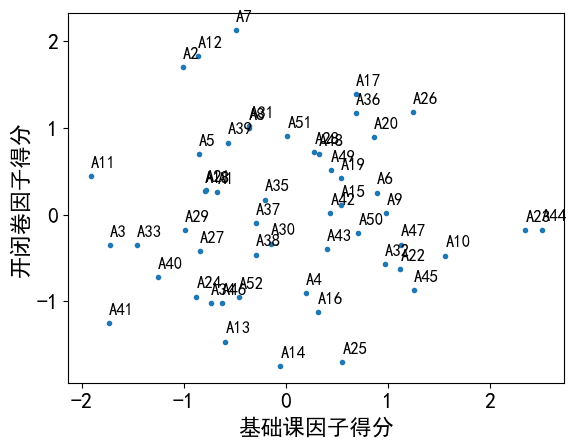

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import decomposition as dc
from scipy.stats import zscore

C = pd.read_excel("Pan11_1_1.xlsx", usecols=np.arange(1, 7))
C = C.values.astype(float)

D = zscore(C)  # 中心标准化
R = np.corrcoef(D.T)  # 求相关系数矩阵，每行是一个变量，故而转置

corrcoef = pd.DataFrame(R)
corrcoef.to_excel("相关系数矩阵.xlsx", sheet_name='correlation coefficient matrix', index=True)

eigenvalues, eigenvectors = np.linalg.eig(R)
eigenvalues_sum = np.cumsum(eigenvalues)  # 求特征值的累加和

print(f"特征值为: {eigenvalues}")
print(f"各公共因子的贡献率: {eigenvalues / 6}")
print(f"累加和为: {eigenvalues_sum}")
print(f"累积贡献率为: {eigenvalues_sum / 6}")

fa = dc.FactorAnalysis(n_components=2)  # 构建模型，两个公共因子
fa.fit(D)  # 求解最大方差的模型
loadings = fa.components_
special_variance = fa.noise_variance_

print(f"载荷矩阵为:\n{loadings}")
print(f"特殊方差为: {special_variance}")

score = fa.fit_transform(D)
w = eigenvalues[:2] / sum(eigenvalues[:2])  # 计算前两个大于1的因子的权重
factor_score = np.dot(score, w)  # 计算每个评价对象的因子总分
total_actual_score = np.sum(C, axis=1)  # 计算每个评价对象的实分总分
eigenvalues_2 = eigenvalues[:2]
ratio = eigenvalues_2 / np.sum(eigenvalues_2)
synthesis_score = score @ ratio

# 构造pandas数据框，第一列到第五列数据分别为序号、因子1得分、因子2得分、因子总分、实分总分
xuhao = ['A' + str(i+1) for i in range(52)]
df = pd.DataFrame(np.c_[xuhao, score, factor_score, total_actual_score, synthesis_score], columns=['序号', 'f1', 'f2', '因子得分', '实分总分', '综合得分'])
sorted_df = df.sort_values(by='因子得分', ascending=False)  # 因子得分从高到低排序
sorted_df2 = df.sort_values(by='实分总分', ascending=False)  # 实体总分从高到低排序
sorted_df3 = df.sort_values(by='综合得分', ascending=False)

display(df, sorted_df, sorted_df2, sorted_df3)

plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

plt.plot(score[:, 0], score[:, 1], '.')
# 标明数据
for i in range(len(xuhao)):
    plt.text(score[i, 0], score[i, 1] + 0.1, xuhao[i], fontsize=12)
plt.xlabel("基础课因子得分")
plt.ylabel("开闭卷因子得分")
plt.savefig("因子得分.png", dpi=500)
plt.show()